In [2]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.under_sampling import EditedNearestNeighbours
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
import tensorflow as tf
import pickle
from tensorflow.keras.layers import Activation
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Reshape
from tensorflow.keras.layers import Input,Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dot
from tensorflow.keras.layers import Lambda
from tensorflow.keras import backend as K
import keras
import random
import numpy as np
import os
from PIL import Image
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.metrics import SparseCategoricalAccuracy


2024-05-13 15:57:49.166690: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-05-13 15:57:49.166794: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-05-13 15:57:49.345522: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
def load_images_from_folder(folder):
    images = []
    labels = []
    for class_label, class_name in enumerate(sorted(os.listdir(folder))):
        class_folder = os.path.join(folder, class_name)
        for filename in os.listdir(class_folder):
            img_path = os.path.join(class_folder, filename)
            img = Image.open(img_path)
            img = img.resize((64, 64))  
            img = np.array(img)
            if img is not None:
                images.append(img)
                labels.append(class_label)
    return np.array(images), np.array(labels)

# Assuming your dataset is stored in a folder called 'dataset'
dataset_folder = '/kaggle/input/paddydoctormedium'

# Load images and labels from the dataset folder
x_data, y_data = load_images_from_folder(dataset_folder)

# Shuffle the data
random_indices = np.random.permutation(len(x_data))
x_data = x_data[random_indices]
y_data = y_data[random_indices]

# Split the data into training and testing sets (assuming 80-20 split)
split_idx = int(0.8 * len(x_data))
x_train, x_test = x_data[:split_idx], x_data[split_idx:]
y_train, y_test = y_data[:split_idx], y_data[split_idx:]

# Normalize the pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flatten the images
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the data generator with augmentation options
datagen = ImageDataGenerator(
    rotation_range=20,      # Random rotation in the range [-20, 20] degrees
    width_shift_range=0.1,  # Random horizontal shift by 10% of the width
    height_shift_range=0.1, # Random vertical shift by 10% of the height
    shear_range=0.2,        # Shear intensity (shear angle in radians)
    zoom_range=0.2,         # Random zoom by 20%
    horizontal_flip=True,   # Random horizontal flip
    fill_mode='nearest'     # Fill mode for points outside the input boundaries
)

In [5]:
x_train = x_train.reshape(-1, 64, 64, 3)

In [6]:
datagen.fit(x_train)

# Example of using the data generator to augment data during training
augmented_data_generator = datagen.flow(x_train, y_train, batch_size=32)

In [7]:
x_train = x_train.reshape(x_train.shape[0],-1)

In [8]:
borderline_smote = SMOTE(random_state=42)
x_train_bls, y_train_bls = borderline_smote.fit_resample(x_train, y_train)

In [9]:
num_classes = len(np.unique(y_train_bls))
y_train_one_hot = to_categorical(y_train_bls, num_classes)
y_test_one_hot = to_categorical(y_test, num_classes)

In [10]:
x_train_bls = x_train_bls.reshape(-1, 64, 64, 3)
x_test = x_test.reshape(-1, 64, 64, 3)


vt

In [11]:
class VisionTransformer(tf.keras.Model):
    def __init__(self, image_size, num_classes, patch_size, num_layers, d_model, num_heads, mlp_dim, dropout_rate=0.3):
        super(VisionTransformer, self).__init__()

        num_patches = (image_size // patch_size) ** 2
        self.patch_dim = 3 * patch_size ** 2  # Assuming input images are RGB

        # Patch embeddings
        self.patch_embeddings = tf.keras.layers.Conv2D(d_model, kernel_size=patch_size, strides=patch_size, padding='valid', input_shape=(image_size, image_size, 3))

        # Positional embeddings
        self.positional_embeddings = tf.keras.layers.Embedding(input_dim=num_patches, output_dim=d_model)

        # Transformer encoder layers
        self.encoder_layers = [TransformerEncoderLayer(d_model, num_heads, mlp_dim, dropout_rate) for _ in range(num_layers)]

        # Classification head
        self.classification_head = tf.keras.layers.Dense(num_classes)

    def call(self, inputs):
        # Patch extraction and embedding
        patches = self.patch_embeddings(inputs)
        batch_size = tf.shape(patches)[0]
        patch_dim = tf.shape(patches)[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dim])

        # Add positional embeddings
        positions = tf.range(start=0, limit=tf.shape(patches)[1], delta=1)
        positions = self.positional_embeddings(positions)

        # Add positional encodings to patch embeddings
        embeddings = patches + positions

        # Transformer encoding
        for encoder_layer in self.encoder_layers:
            embeddings = encoder_layer(embeddings)

        # Classification head
        logits = self.classification_head(embeddings[:, 0])

        return logits

class TransformerEncoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, mlp_dim, dropout_rate=0.3):
        super(TransformerEncoderLayer, self).__init__()
        self.attention = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model, dropout=dropout_rate)
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(mlp_dim, activation='relu'),
            tf.keras.layers.Dropout(dropout_rate),
            tf.keras.layers.Dense(d_model)
        ])
        self.layer_norm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layer_norm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(dropout_rate)
        self.dropout2 = tf.keras.layers.Dropout(dropout_rate)

    def call(self, inputs):
        # Self-attention
        attention_output = self.attention(inputs, inputs)
        attention_output = self.dropout1(attention_output)
        # Residual connection and layer normalization
        attention_output = self.layer_norm1(inputs + attention_output)

        # Feedforward network
        ffn_output = self.ffn(attention_output)
        ffn_output = self.dropout2(ffn_output)
        # Residual connection and layer normalization
        ffn_output = self.layer_norm2(attention_output + ffn_output)

        return ffn_output

cnn

In [12]:
from tensorflow.keras.callbacks import EarlyStopping,Callback

class CustomCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('val_accuracy') > 0.92:
            self.model.stop_training = True

# Instantiate the custom callback
callback1 = CustomCallback()

In [19]:
cnn_model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(64, 64, 3)),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    # Add more Conv2D and MaxPooling2D layers as needed
])

# Define the Vision Transformer (ViT) model
class VisionTransformer(tf.keras.Model):
    def __init__(self, num_classes, patch_size, num_layers, d_model, num_heads, mlp_dim, dropout_rate=0.3):
        super(VisionTransformer, self).__init__()

        # Patch embeddings
        num_patches = (64 // patch_size) ** 2
        self.patch_dim = 64  # Output channels of the CNN
        self.patch_embeddings = tf.keras.layers.Conv2D(d_model, kernel_size=patch_size, strides=patch_size, padding='valid', activation='relu')

        # Positional embeddings
        self.positional_embeddings = tf.keras.layers.Embedding(input_dim=num_patches, output_dim=d_model)

        # Transformer encoder layers
        self.encoder_layers = [TransformerEncoderLayer(d_model, num_heads, mlp_dim, dropout_rate) for _ in range(num_layers)]

        # Classification head
        self.classification_head = tf.keras.layers.Dense(num_classes)

    def call(self, inputs):
        # CNN feature extraction
        cnn_features = cnn_model(inputs)

        # Patch embedding
        patches = self.patch_embeddings(cnn_features)
        batch_size = tf.shape(patches)[0]
        patch_dim = tf.shape(patches)[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dim])

        # Add positional embeddings
        positions = tf.range(start=0, limit=tf.shape(patches)[1], delta=1)
        positions = self.positional_embeddings(positions)

        # Add positional encodings to patch embeddings
        embeddings = patches + positions

        # Transformer encoding
        for encoder_layer in self.encoder_layers:
            embeddings = encoder_layer(embeddings)

        # Classification head
        logits = self.classification_head(embeddings[:, 0])

        return logits
    
    
    
    def get_config(self):
        config = super(VisionTransformer, self).get_config()
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

# Instantiate the ViT model
model1 = VisionTransformer(num_classes=13, patch_size=8, num_layers=6, d_model=256, num_heads=8, mlp_dim=512)

# Compile the model
model1.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['accuracy'])

# Train the model
history2 = model1.fit(x_train_bls, y_train_bls, epochs=100, batch_size=64, validation_data=(x_test, y_test),callbacks = callback1)

# Evaluate the model


Epoch 1/100
  2/391 ━━━━━━━━━━━━━━━━━━━━ 28s 74ms/step - accuracy: 0.1055 - loss: 3.2675   

I0000 00:00:1715616172.545391     187 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
W0000 00:00:1715616172.582240     187 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.1092 - loss: 2.6228

W0000 00:00:1715616198.817888     189 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update
W0000 00:00:1715616201.439400     186 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


391/391 ━━━━━━━━━━━━━━━━━━━━ 59s 81ms/step - accuracy: 0.1093 - loss: 2.6222 - val_accuracy: 0.3171 - val_loss: 2.0290
Epoch 2/100
  3/391 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.3872 - loss: 1.9124

W0000 00:00:1715616204.414613     187 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.5467 - loss: 1.4213 - val_accuracy: 0.6770 - val_loss: 1.0387
Epoch 3/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.8302 - loss: 0.5479 - val_accuracy: 0.7895 - val_loss: 0.6880
Epoch 4/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.9153 - loss: 0.2855 - val_accuracy: 0.7948 - val_loss: 0.6780
Epoch 5/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.9466 - loss: 0.1794 - val_accuracy: 0.8669 - val_loss: 0.4680
Epoch 6/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.9669 - loss: 0.1091 - val_accuracy: 0.8586 - val_loss: 0.5075
Epoch 7/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.9763 - loss: 0.0788 - val_accuracy: 0.8764 - val_loss: 0.4473
Epoch 8/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.9817 - loss: 0.0650 - val_accuracy: 0.8712 - val_loss: 0.4592
Epoch 9/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.9816 - loss: 0.0609 - val_

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

In [22]:
loss,accuracy = model1.evaluate(x_test,y_test)
print("testing accuracy:", accuracy)


loss = history2.history['loss'][-1]

print("Final Loss:", loss)

 19/102 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9160 - loss: 0.5404

W0000 00:00:1715617786.953251     189 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9207 - loss: 0.4484
testing accuracy: 0.9235747456550598
Final Loss: 0.007074137683957815


W0000 00:00:1715617789.301776     187 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


In [23]:
y1_pred = model1.predict(x_test)

 16/102 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

W0000 00:00:1715617806.403524     188 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


102/102 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step


W0000 00:00:1715617809.160722     187 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


In [24]:
threshold = 0.5  # You may need to adjust this threshold based on your problem
y_pred_binary = np.where(y1_pred >= threshold, 1, 0)



In [25]:


# Now y_pred_binary contains binary predictions based on the threshold


precision = precision_score(y_test_one_hot, y_pred_binary,average='micro')
print("Precision:", precision)

recall = recall_score(y_test_one_hot, y_pred_binary,average='micro')
print("Recall:", recall)

f1 = f1_score(y_test_one_hot, y_pred_binary,average='micro')
print("F1 Score:", f1)

auc_roc = roc_auc_score(y_test_one_hot, y_pred_binary,average='micro')
print("AUC-ROC Score:", auc_roc)

Precision: 0.20440411219697932
Recall: 0.9926040061633282
F1 Score: 0.3389991054044098
AUC-ROC Score: 0.8353235747303543


In [26]:
class_report = classification_report(y_test_one_hot, y_pred_binary)
print("Classification Report:")
print(class_report)

Classification Report:
              precision    recall  f1-score   support

           0       0.13      0.97      0.23       116
           1       0.23      0.99      0.37       110
           2       0.14      0.99      0.25        93
           3       0.13      0.99      0.23       102
           4       0.19      1.00      0.32       452
           5       0.14      0.99      0.24       262
           6       0.19      0.97      0.32       185
           7       0.25      1.00      0.40       429
           8       0.19      0.99      0.32       216
           9       0.38      0.99      0.55       484
          10       0.23      1.00      0.37       366
          11       0.24      1.00      0.38       269
          12       0.17      1.00      0.30       161

   micro avg       0.20      0.99      0.34      3245
   macro avg       0.20      0.99      0.33      3245
weighted avg       0.22      0.99      0.36      3245
 samples avg       0.22      0.99      0.36      3245



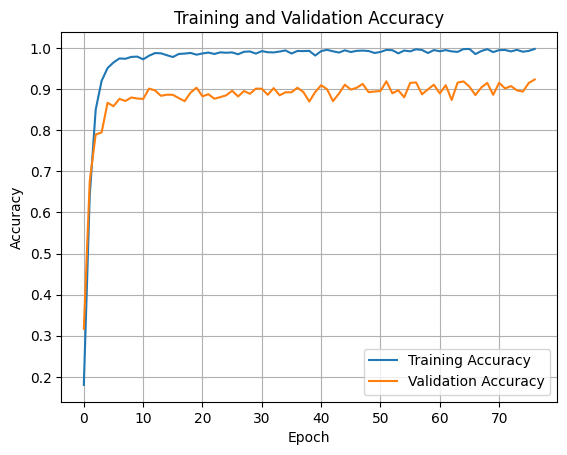

In [27]:
import matplotlib.pyplot as plt

# Extract training and validation accuracy from history
train_acc = history2.history['accuracy']
val_acc = history2.history['val_accuracy']

# Create the plot
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

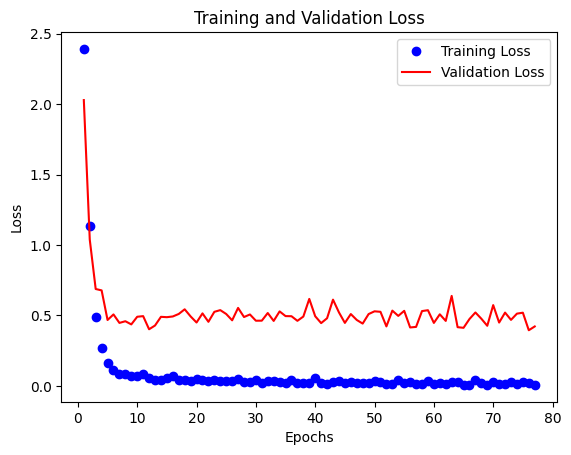

In [28]:
training_loss = history2.history['loss']
validation_loss = history2.history['val_loss']
epochs = range(1, len(training_loss) + 1)

plt.plot(epochs, training_loss, 'bo', label='Training Loss')
plt.plot(epochs, validation_loss, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

[[ 98   0   1   0   8   2   0   2   0   1   2   1   1]
 [  1  99   1   0   1   4   0   0   3   0   1   0   0]
 [  0   1  83   2   3   0   0   0   2   0   1   0   1]
 [  0   0   0  93   2   2   0   0   0   0   2   3   0]
 [  0   0   0   0 437   4   0   2   1   2   3   2   1]
 [  2   0   1   0   5 246   0   1   1   2   4   0   0]
 [  0   0   0   0  15   4 155   4   1   2   3   1   0]
 [  4   0   0   1   6   3   1 397   5   7   4   1   0]
 [  0   1   0   2   9   2   0   6 189   2   2   2   1]
 [  1   0   0   0   3   4   0   6   0 463   6   1   0]
 [  0   0   0   1   5   5   0   2   3   1 349   0   0]
 [  0   0   2   3  10   3   0   1   0   1   4 232  13]
 [  0   0   0   1   2   0   0   0   0   0   1   1 156]]


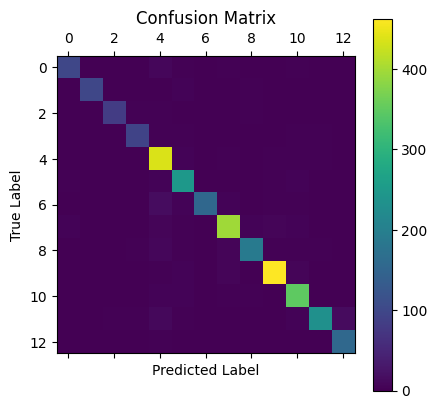

In [67]:
from sklearn.metrics import confusion_matrix

# Get predictions from your model

y_pred_classes = np.argmax(y1_pred, axis=1)  # Convert one-hot to class labels

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Print or plot the confusion matrix (various ways to visualize it)
print(cm)

# Example using matplotlib for basic visualization
plt.matshow(cm)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.colorbar()
plt.show()

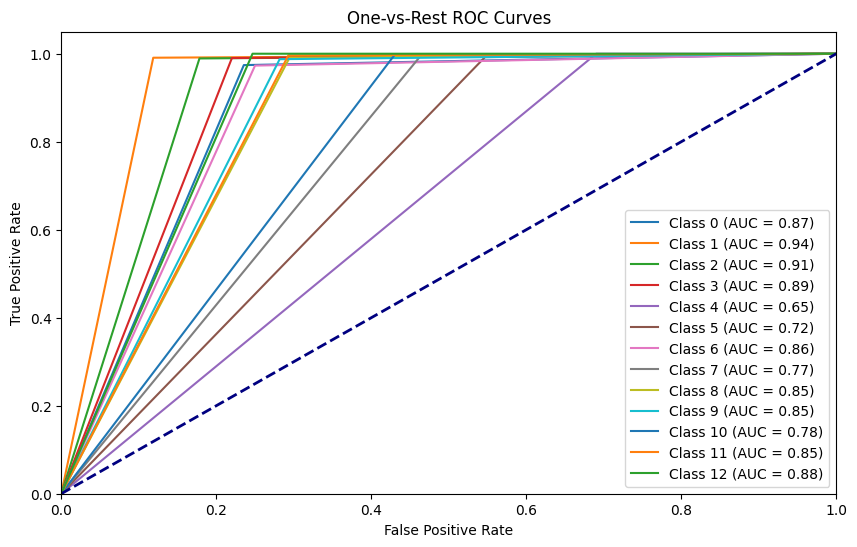

In [68]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming `y_test` are the true labels and `y_pred_probs` are the predicted probabilities
# Compute OvR ROC curve and ROC area for each class
plt.figure(figsize=(10, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test == i, y_pred_binary[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.show()


In [33]:
vit_predictions = model1.predict(x_test)

102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [69]:
model1.summary()

Model: "vision_transformer_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ ?                      │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ ?                      │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_layer_18    │ ?                      │     2,367,488 │
│ (TransformerEncoderLayer)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_layer_19    │ ?                      │     2,367,488 │
│ (TransformerEncoderLayer)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_layer_20    │ ?                      │     2,367,488 │
│ (TransformerEncoderLayer)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_layer_21    │ ?                      │     2,367,488 │
│ (TransformerEncoderLayer)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_layer_22    │ ?                      │     2,367,488 │
│ (TransformerEncoderLayer)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_layer_23    │ ?                      │     2,367,488 │
│ (TransformerEncoderLayer)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ ?                      │         3,341 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,820,457 (174.79 MB)

 Trainable params: 15,273,485 (58.26 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 30,546,972 (116.53 MB)

# Octave Convolution


In [34]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.under_sampling import EditedNearestNeighbours
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
import tensorflow as tf
import pickle
from tensorflow.keras.layers import Activation
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Reshape
from tensorflow.keras.layers import Input,Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dot
from tensorflow.keras.layers import Lambda
from tensorflow.keras import backend as K
import keras
import random
import numpy as np
import os
from PIL import Image
from tensorflow.keras.utils import to_categorical

In [35]:
from keras.layers import Conv2D, AveragePooling2D, UpSampling2D
from keras.layers import add


def initial_octconv(ip, filters, kernel_size=(3, 3), strides=(1, 1),
                    alpha=0.5, padding='same', dilation=None, bias=False):
    """
    Initializes the Octave Convolution architecture.

    Accepts a single input tensor, and returns a pair of tensors.
    The first tensor is the high frequency pathway.
    The second tensor is the low frequency pathway.

    # Arguments:
        ip: keras tensor.
        filters: number of filters in conv layer.
        kernel_size: conv kernel size.
        strides: strides of the conv.
        alpha: float between [0, 1]. Defines the ratio of filters
            allocated to the high frequency and low frequency
            branches of the octave conv.
        padding: padding mode.
        dilation: dilation conv kernel.
        bias: bool, whether to use bias or not.

    # Returns:
        a pair of tensors:
            - x_high: high frequency pathway.
            - x_low: low frequency pathway.
    """
    if dilation is None:
        dilation = (1, 1)

    high_low_filters = int(alpha * filters)
    high_high_filters = filters - high_low_filters

    if strides[0] > 1:
        ip = AveragePooling2D()(ip)

    # High path
    x_high = Conv2D(high_high_filters, kernel_size, padding=padding,
                    dilation_rate=dilation, use_bias=bias,
                    kernel_initializer='he_normal')(ip)

    # Low path
    x_high_low = AveragePooling2D(pool_size=(2, 2))(ip)
    x_low = Conv2D(high_low_filters, kernel_size, padding=padding,
                   dilation_rate=dilation, use_bias=bias,
                   kernel_initializer='he_normal')(x_high_low)

    return x_high, x_low


def final_octconv(ip_high, ip_low, filters, kernel_size=(3, 3), strides=(1, 1),
                  padding='same', dilation=None, bias=False):
    """
    Ends the Octave Convolution architecture.

    Accepts two input tensors, and returns a single output tensor.
    The first input tensor is the high frequency pathway.
    The second input tensor is the low frequency pathway.

    # Arguments:
        ip_high: keras tensor.
        ip_low: keras tensor.
        filters: number of filters in conv layer.
        kernel_size: conv kernel size.
        strides: strides of the conv.
        padding: padding mode.
        dilation: dilation conv kernel.
        bias: bool, whether to use bias or not.

    # Returns:
        a single Keras tensor:
            - x_high: The merged high frequency pathway.
    """
    if dilation is None:
        dilation = (1, 1)

    if strides[0] > 1:
        avg_pool = AveragePooling2D(pool_size=(2, 2))

        ip_high = avg_pool(ip_high)
        ip_low = avg_pool(ip_low)

    # High path
    x_high_high = Conv2D(filters, kernel_size, padding=padding,
                         dilation_rate=dilation, use_bias=bias,
                         kernel_initializer='he_normal')(ip_high)

    # Low path
    x_low_high = Conv2D(filters, kernel_size, padding=padding,
                        dilation_rate=dilation, use_bias=bias,
                        kernel_initializer='he_normal')(ip_low)

    x_low_high = UpSampling2D(interpolation='nearest')(x_low_high)

    # Merge paths
    x = add([x_high_high, x_low_high])

    return x


def octconv_block(ip_high, ip_low, filters, kernel_size=(3, 3), strides=(1, 1),
                  alpha=0.5, padding='same', dilation=None, bias=False):
    """
    Constructs an Octave Convolution block.

    Accepts a pair of input tensors, and returns a pair of tensors.
    The first tensor is the high frequency pathway for both ip/op.
    The second tensor is the low frequency pathway for both ip/op.

    # Arguments:
        ip_high: keras tensor.
        ip_low: keras tensor.
        filters: number of filters in conv layer.
        kernel_size: conv kernel size.
        strides: strides of the conv.
        alpha: float between [0, 1]. Defines the ratio of filters
            allocated to the high frequency and low frequency
            branches of the octave conv.
        padding: padding mode.
        dilation: dilation conv kernel.
        bias: bool, whether to use bias or not.

    # Returns:
        a pair of tensors:
            - x_high: high frequency pathway.
            - x_low: low frequency pathway.
    """
    if dilation is None:
        dilation = (1, 1)

    low_low_filters = high_low_filters = int(alpha * filters)
    high_high_filters = low_high_filters = filters - low_low_filters

    avg_pool = AveragePooling2D(pool_size=(2, 2))

    if strides[0] > 1:
        ip_high = avg_pool(ip_high)
        ip_low = avg_pool(ip_low)

    # High path
    x_high_high = Conv2D(high_high_filters, kernel_size, padding=padding,
                         dilation_rate=dilation, use_bias=bias,
                         kernel_initializer='he_normal')(ip_high)

    x_low_high = Conv2D(low_high_filters, kernel_size, padding=padding,
                        dilation_rate=dilation, use_bias=bias,
                        kernel_initializer='he_normal')(ip_low)
    x_low_high = UpSampling2D(interpolation='nearest')(x_low_high)

    # Low path
    x_low_low = Conv2D(low_low_filters, kernel_size, padding=padding,
                       dilation_rate=dilation, use_bias=bias,
                       kernel_initializer='he_normal')(ip_low)

    x_high_low = avg_pool(ip_high)
    x_high_low = Conv2D(high_low_filters, kernel_size, padding=padding,
                        dilation_rate=dilation, use_bias=bias,
                        kernel_initializer='he_normal')(x_high_low)

    # Merge paths
    x_high = add([x_high_high, x_low_high])
    x_low = add([x_low_low, x_high_low])

    return x_high, x_low


if __name__ == '__main__':

    visualize_model = True

    from keras.models import Model
    from keras.layers import Input

    ip = Input(shape=(32, 32, 3))

    xh, xl = initial_octconv(ip, filters=48)

    xh, xl = octconv_block(xh, xl, filters=64)
    xh, xl = octconv_block(xh, xl, filters=96, strides=(2, 2))

    x = final_octconv(xh, xl, filters=10)

    model = Model(ip, x)
    model.summary()


Model: "functional_25"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_23      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_3 │ (None, 16, 16, 3) │          0 │ input_layer_23[0… │
│ (AveragePooling2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 16, 16,    │        648 │ average_pooling2… │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 32, 32,    │        648 │ input_layer_23[0… │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 16, 16,    │      6,912 │ conv2d_21[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 32, 32,    │      6,912 │ conv2d_20[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_3     │ (None, 32, 32,    │          0 │ conv2d_23[0][0]   │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_4 │ (None, 16, 16,    │          0 │ conv2d_20[0][0]   │
│ (AveragePooling2D)  │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 32, 32,    │          0 │ conv2d_22[0][0],  │
│                     │ 32)               │            │ up_sampling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 16, 16,    │      6,912 │ conv2d_21[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 16, 16,    │      6,912 │ average_pooling2… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_5 │ (None, 8, 8, 32)  │          0 │ add_5[0][0],      │
│ (AveragePooling2D)  │                   │            │ add_6[0][0],      │
│                     │                   │            │ average_pooling2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 16, 16,    │          0 │ conv2d_24[0][0],  │
│                     │ 32)               │            │ conv2d_25[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 8, 8, 48)  │     13,824 │ average_pooling2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 8, 8, 48)  │     13,824 │ average_pooling2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 8, 8, 48)  │     13,824 │ average_pooling2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 16, 16,    │     13,824 │ average_pooling2… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 92,880 (362.81 KB)

 Trainable params: 92,880 (362.81 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'



from keras.layers import ReLU, BatchNormalization
from keras import backend as K



def initial_oct_conv_bn_relu(ip, filters, kernel_size=(3, 3), strides=(1, 1),
                             alpha=0.5, padding='same', dilation=None, bias=False,
                             activation=True):

    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1

    x_high, x_low = initial_octconv(ip, filters, kernel_size, strides, alpha,
                                    padding, dilation, bias)

    relu = ReLU()
    x_high = BatchNormalization(axis=channel_axis)(x_high)
    if activation:
        x_high = relu(x_high)

    x_low = BatchNormalization(axis=channel_axis)(x_low)
    if activation:
        x_low = relu(x_low)

    return x_high, x_low


def final_oct_conv_bn_relu(ip_high, ip_low, filters, kernel_size=(3, 3), strides=(1, 1),
                           padding='same', dilation=None, bias=False, activation=True):

    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1

    x = final_octconv(ip_high, ip_low, filters, kernel_size, strides,
                      padding, dilation, bias)

    x = BatchNormalization(axis=channel_axis)(x)
    if activation:
        x = ReLU()(x)

    return x


def oct_conv_bn_relu(ip_high, ip_low, filters, kernel_size=(3, 3), strides=(1, 1),
                     alpha=0.5, padding='same', dilation=None, bias=False, activation=True):

    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1

    x_high, x_low = octconv_block(ip_high, ip_low, filters, kernel_size, strides, alpha,
                                  padding, dilation, bias)

    relu = ReLU()
    x_high = BatchNormalization(axis=channel_axis)(x_high)
    if activation:
        x_high = relu(x_high)

    x_low = BatchNormalization(axis=channel_axis)(x_low)
    if activation:
        x_low = relu(x_low)

    return x_high, x_low

In [37]:
import os
from keras.layers import BatchNormalization
from keras.layers import Conv2D
from keras.layers import Dense
from keras.layers import GlobalAveragePooling2D
from keras.layers import GlobalMaxPooling2D
from keras.layers import Input
from keras.layers import MaxPool2D
from keras.layers import ReLU
from keras.layers import add
from keras.models import Model
from keras.utils import get_source_inputs

from keras import backend as K
from keras_applications.imagenet_utils import _obtain_input_shape



def _conv_block(ip, filters, kernel_size=(3, 3), strides=(1, 1),
                padding='same', bias=False):
    x = Conv2D(filters, kernel_size, strides=strides, padding=padding, use_bias=bias,
               kernel_initializer='he_normal')(ip)

    return x


def _conv_bn_relu(ip, filters, kernel_size=(3, 3), strides=(1, 1),
                  padding='same', bias=False, activation=True):

    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1

    x = _conv_block(ip, filters, kernel_size, strides, padding, bias)
    x = BatchNormalization(axis=channel_axis)(x)
    if activation:
        x = ReLU()(x)

    return x


def _octresnet_bottleneck_block(ip, filters, alpha=0.5, strides=(1, 1),
                                downsample_shortcut=False, first_block=False,
                                expansion=4):

    if first_block:
        x_high_res, x_low_res = initial_oct_conv_bn_relu(ip, filters, kernel_size=(1, 1),
                                                         alpha=alpha)

        x_high, x_low = oct_conv_bn_relu(x_high_res, x_low_res, filters, kernel_size=(3, 3),
                                         strides=strides, alpha=alpha)

    else:
        x_high_res, x_low_res = ip
        x_high, x_low = oct_conv_bn_relu(x_high_res, x_low_res, filters, kernel_size=(1, 1),
                                         alpha=alpha)

        x_high, x_low = oct_conv_bn_relu(x_high, x_low, filters, kernel_size=(3, 3),
                                         strides=strides, alpha=alpha)

    final_out_filters = int(filters * expansion)
    x_high, x_low = oct_conv_bn_relu(x_high, x_low, filters=final_out_filters,
                                     kernel_size=(1, 1), alpha=alpha, activation=False)

    if downsample_shortcut:
        x_high_res, x_low_res = oct_conv_bn_relu(x_high_res, x_low_res,
                                                 final_out_filters, kernel_size=(1, 1),
                                                 strides=strides, alpha=alpha,
                                                 activation=False)

    x_high = add([x_high, x_high_res])
    x_low = add([x_low, x_low_res])

    x_high = ReLU()(x_high)
    x_low = ReLU()(x_low)

    return x_high, x_low


def _octresnet_final_bottleneck_block(ip, filters, alpha=0.5, strides=(1, 1),
                                      downsample_shortcut=False,
                                      expansion=4):

    x_high_res, x_low_res = ip

    x_high, x_low = oct_conv_bn_relu(x_high_res, x_low_res, filters, kernel_size=(1, 1),
                                     alpha=alpha)

    x_high, x_low = oct_conv_bn_relu(x_high, x_low, filters, kernel_size=(3, 3),
                                     strides=strides, alpha=alpha)

    final_filters = int(filters * expansion)
    x_high = final_oct_conv_bn_relu(x_high, x_low, final_filters, kernel_size=(1, 1),
                                    activation=False)

    if downsample_shortcut:
        x_high_res = final_oct_conv_bn_relu(x_high_res, x_low_res, final_filters, kernel_size=(1, 1),
                                            strides=strides, activation=False)

    x = add([x_high, x_high_res])
    x = ReLU()(x)

    return x


def _bottleneck_original(ip, filters, strides=(1, 1), downsample_shortcut=False,
                         expansion=4):

    final_filters = int(filters * expansion)

    shortcut = ip

    x = _conv_bn_relu(ip, filters, kernel_size=(1, 1))
    x = _conv_bn_relu(x, filters, kernel_size=(3, 3), strides=strides)
    x = _conv_bn_relu(x, final_filters, kernel_size=(1, 1), activation=False)

    if downsample_shortcut:
        shortcut = _conv_block(shortcut, final_filters, kernel_size=(1, 1),
                               strides=strides)

    x = add([x, shortcut])
    x = ReLU()(x)

    return x


def OctaveResNet(layers,
                 include_top=True,
                 weights=None,
                 input_tensor=None,
                 input_shape=None,
                 pooling=None,
                 classes=1000,
                 alpha=0.5,
                 expansion=1,
                 initial_filters=64,
                 initial_strides=False,
                 **kwargs):
    """ Instantiates a Octave ResNet architecture.

    # Arguments
        layers: list of integers defining the depth of the network and
            the number of octave conv blocks per level of the
            network.
        include_top: whether to include the fully-connected
            layer at the top of the network.
        weights: one of `None` (random initialization),
              'imagenet' (pre-training on ImageNet),
              or the path to the weights file to be loaded.
        input_tensor: optional Keras tensor
            (i.e. output of `layers.Input()`)
            to use as image input for the model.
        input_shape: optional shape tuple, only to be specified
            if `include_top` is False (otherwise the input shape
            has to be `(224, 224, 3)` (with `'channels_last'` data format)
            or `(3, 224, 224)` (with `'channels_first'` data format).
            It should have exactly 3 inputs channels,
            and width and height should be no smaller than 32.
            E.g. `(200, 200, 3)` would be one valid value.
        pooling: optional pooling mode for feature extraction
            when `include_top` is `False`.
            - `None` means that the output of the model will be
                the 4D tensor output of the
                last convolutional layer.
            - `avg` means that global average pooling
                will be applied to the output of the
                last convolutional layer, and thus
                the output of the model will be a 2D tensor.
            - `max` means that global max pooling will
                be applied.
        classes: optional number of classes to classify images
            into, only to be specified if `include_top` is True, and
            if no `weights` argument is specified.
        alpha: float between [0, 1]. Defines the ratio of filters
            allocated to the high frequency and low frequency
            branches of the octave conv.
        expansion: int/float. Multiplicative factor to increase the
            number of filters in each octave block.
        initial_filters: number of filters in the first convolution
            layer. Determines how many parameters the network will
            have.
        initial_strides: bool to determine whether to apply a strided
            convolution and max pooling before any octave conv
            block. Set to True for ImageNet models and False for
            CIFAR models.

    # Returns
        A Keras model instance.

    # Raises
        ValueError: in case of invalid argument for `weights`,
            or invalid input shape.
`       ValueError: If `alpha` is < 0 or > 1.
        ValueError: If `layers` is not a list or a tuple
            of integers.
    """

    if not (weights in {'imagenet', None} or os.path.exists(weights)):
        raise ValueError('The `weights` argument should be either '
                         '`None` (random initialization), `imagenet` '
                         '(pre-training on ImageNet), '
                         'or the path to the weights file to be loaded.')

    if weights == 'imagenet' and include_top and classes != 1000:
        raise ValueError('If using `weights` as `"imagenet"` with `include_top`'
                         ' as true, `classes` should be 1000')

    if alpha < 0. or alpha > 1.:
        raise ValueError('`alpha` must be between 0 and 1. Current alpha = '
                         '%f' % alpha)

    if type(layers) not in [list, tuple]:
        raise ValueError('`layers` must be a list/tuple of integers. '
                         'Current layers = ', layers)

    # Force convert all layer values to integers
    layers = [int(x) for x in layers]

    # Determine proper input shape
    input_shape = _obtain_input_shape(input_shape,
                                      default_size=224,
                                      min_size=32,
                                      data_format=K.image_data_format(),
                                      require_flatten=include_top,
                                      weights=weights)

    if input_tensor is None:
        img_input = Input(shape=input_shape)
    else:
        if not K.is_keras_tensor(input_tensor):
            img_input = Input(tensor=input_tensor, shape=input_shape)
        else:
            img_input = input_tensor

    if initial_strides:
        initial_strides = (2, 2)

    else:
        initial_strides = (1, 1)

    x = _conv_bn_relu(img_input, filters=64, kernel_size=(7, 7), strides=initial_strides)

    if initial_strides:
        x = MaxPool2D((3, 3), strides=(2, 2), padding='same')(x)

    num_filters = initial_filters
    num_blocks = len(layers)

    for i in range(num_blocks - 1):
        for j in range(layers[i]):
            if j == 0:
                strides = (2, 2)
                downsample_shortcut = True

            else:
                strides = (1, 1)
                downsample_shortcut = False

            # first block has no downsample, no shortcut
            if i == 0 and j == 0:
                first_block = True
                strides = (1, 1)
                downsample_shortcut = True

            else:
                first_block = False

            x = _octresnet_bottleneck_block(x, num_filters, alpha, strides, downsample_shortcut,
                                            first_block, expansion)

        # double number of filters per block
        num_filters *= 2

    # final block
    for j in range(layers[-1]):
        if j == 0:
            strides = (2, 2)
            x = _octresnet_final_bottleneck_block(x, num_filters, alpha, strides,
                                                  downsample_shortcut=True, expansion=expansion)

        else:
            strides = (1, 1)
            x = _bottleneck_original(x, num_filters, strides, expansion=expansion)

    if include_top:
        x = GlobalAveragePooling2D(name='avg_pool')(x)
        x = Dense(classes, activation='softmax', name='fc')(x)
    else:
        if pooling == 'avg':
            x = GlobalAveragePooling2D(name='avg_pool')(x)
        elif pooling == 'max':
            x = GlobalMaxPooling2D(name='max_pool')(x)

    # Ensure that the model takes into account
    # any potential predecessors of `input_tensor`.
    if input_tensor is not None:
        inputs = get_source_inputs(input_tensor)
    else:
        inputs = img_input

    model = Model(inputs, x, name='OctaveResNet')

    return model


def OctaveResNet50(include_top=True,
                   weights=None,
                   input_tensor=None,
                   input_shape=None,
                   pooling=None,
                   classes=1000,
                   alpha=0.5,
                   expansion=4,
                   initial_filters=64,
                   initial_strides=True,
                   **kwargs):

    return OctaveResNet([3, 4, 6, 3],
                        include_top,
                        weights,
                        input_tensor,
                        input_shape,
                        pooling,
                        classes,
                        alpha,
                        expansion,
                        initial_filters,
                        initial_strides,
                        **kwargs)


def OctaveResNet101(include_top=True,
                    weights=None,
                    input_tensor=None,
                    input_shape=None,
                    pooling=None,
                    classes=1000,
                    alpha=0.5,
                    expansion=4,
                    initial_filters=64,
                    initial_strides=True,
                    **kwargs):

    return OctaveResNet([3, 4, 23, 3],
                        include_top,
                        weights,
                        input_tensor,
                        input_shape,
                        pooling,
                        classes,
                        alpha,
                        expansion,
                        initial_filters,
                        initial_strides,
                        **kwargs)


def OctaveResNet152(include_top=True,
                    weights=None,
                    input_tensor=None,
                    input_shape=None,
                    pooling=None,
                    classes=1000,
                    alpha=0.5,
                    expansion=4,
                    initial_filters=64,
                    initial_strides=True,
                    **kwargs):

    return OctaveResNet([3, 8, 36, 3],
                        include_top,
                        weights,
                        input_tensor,
                        input_shape,
                        pooling,
                        classes,
                        alpha,
                        expansion,
                        initial_filters,
                        initial_strides,
                        **kwargs)


if __name__ == '__main__':
    model = OctaveResNet50(input_shape=(256, 256, 3), classes=1000,
                           alpha=0.125, expansion=4,
                           initial_filters=64,
                           initial_strides=True)
   

In [38]:
model2 = OctaveResNet50(include_top=True,
                        weights=None,
                        input_tensor=None,
                        input_shape=(64,64,3),
                        pooling='avg',
                        classes=13,
                        alpha=0.125,
                        expansion=4,
                        initial_filters=64,
                        initial_strides=True)
model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [39]:
from tensorflow.keras.callbacks import EarlyStopping,Callback

class CustomCallback1(Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('val_accuracy') > 0.959:
            self.model.stop_training = True

# Instantiate the custom callback
callback2 = CustomCallback1()

In [40]:
# Train the model 
history1 = model2.fit(x_train_bls,y_train_one_hot,epochs=100,batch_size=64,validation_data=(x_test,y_test_one_hot),callbacks = callback2)

Epoch 1/100
  1/391 ━━━━━━━━━━━━━━━━━━━━ 14:44:54 136s/step - accuracy: 0.0469 - loss: 3.7875

W0000 00:00:1715618190.494451     187 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.4066 - loss: 2.3341

W0000 00:00:1715618289.671286     187 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update
W0000 00:00:1715618301.219429     188 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


391/391 ━━━━━━━━━━━━━━━━━━━━ 260s 318ms/step - accuracy: 0.4069 - loss: 2.3326 - val_accuracy: 0.3063 - val_loss: 2.3589
Epoch 2/100
  1/391 ━━━━━━━━━━━━━━━━━━━━ 1:06 170ms/step - accuracy: 0.5625 - loss: 2.1542

W0000 00:00:1715618314.787179     187 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


391/391 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - accuracy: 0.6223 - loss: 1.4000 - val_accuracy: 0.2505 - val_loss: 2.4888
Epoch 3/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 35s 88ms/step - accuracy: 0.6401 - loss: 1.3562 - val_accuracy: 0.1673 - val_loss: 5.8518
Epoch 4/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 35s 89ms/step - accuracy: 0.6961 - loss: 1.0855 - val_accuracy: 0.5911 - val_loss: 1.3864
Epoch 5/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 35s 89ms/step - accuracy: 0.7576 - loss: 0.8392 - val_accuracy: 0.3279 - val_loss: 3.5149
Epoch 6/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 35s 89ms/step - accuracy: 0.7792 - loss: 0.7356 - val_accuracy: 0.6703 - val_loss: 1.0434
Epoch 7/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 35s 89ms/step - accuracy: 0.8929 - loss: 0.3422 - val_accuracy: 0.7904 - val_loss: 0.7190
Epoch 8/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 35s 88ms/step - accuracy: 0.8690 - loss: 0.4470 - val_accuracy: 0.8650 - val_loss: 0.4497
Epoch 9/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 89ms/step - accuracy: 0.9065 - loss: 0.3110 - val_

In [52]:
loss,accuracy = model2.evaluate(x_test,y_test_one_hot)
print("testing accuracy:", accuracy)


loss = history1.history['loss'][-1]

print("Final Loss:", loss)


y_pred2 = model2.predict(x_test)

import numpy as np

# Assuming y_pred is continuous probabilities
threshold = 0.5  # Set your desired threshold here
y_pred_binary2 = np.where(y_pred2 >= threshold, 1, 0)

# Now y_pred_binary contains binary predictions based on the threshold


precision = precision_score(y_test_one_hot, y_pred_binary2,average='micro')
print("Precision:", precision)

recall = recall_score(y_test_one_hot, y_pred_binary2,average='micro')
print("Recall:", recall)

f1 = f1_score(y_test_one_hot, y_pred_binary2,average='micro')
print("F1 Score:", f1)

auc_roc = roc_auc_score(y_test_one_hot, y_pred_binary2,average='micro')
print("AUC-ROC Score:", auc_roc)


class_report = classification_report(y_test_one_hot, y_pred_binary2)
print("Classification Report:")
print(class_report)

  7/102 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9403 - loss: 0.2638

W0000 00:00:1715621041.770668     186 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


102/102 ━━━━━━━━━━━━━━━━━━━━ 12s 71ms/step - accuracy: 0.9586 - loss: 0.1906


W0000 00:00:1715621048.965246     189 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


testing accuracy: 0.9620955586433411
Final Loss: 0.009135724045336246
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
Precision: 0.964097802537914
Recall: 0.9599383667180277
F1 Score: 0.9620135886349598
AUC-ROC Score: 0.9784797123780175
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93       116
           1       0.97      0.97      0.97       110
           2       0.99      0.96      0.97        93
           3       1.00      0.95      0.97       102
           4       0.95      0.97      0.96       452
           5       0.97      0.96      0.96       262
           6       0.97      0.94      0.95       185
           7       0.94      0.97      0.96       429
           8       0.96      0.93      0.94       216
           9       0.97      0.97      0.97       484
          10       0.99      0.96      0.97       366
          11       0.97      0.96      0.96       269
          12       0.96      0.99      0.97

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


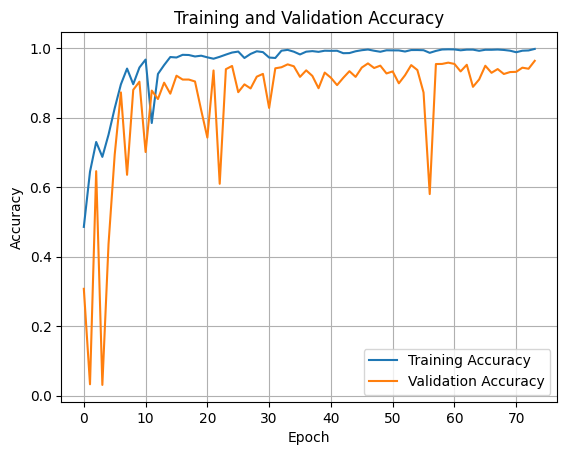

In [55]:
import matplotlib.pyplot as plt

# Extract training and validation accuracy from history
train_acc = history1.history['accuracy']
val_acc = history1.history['val_accuracy']

# Create the plot
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

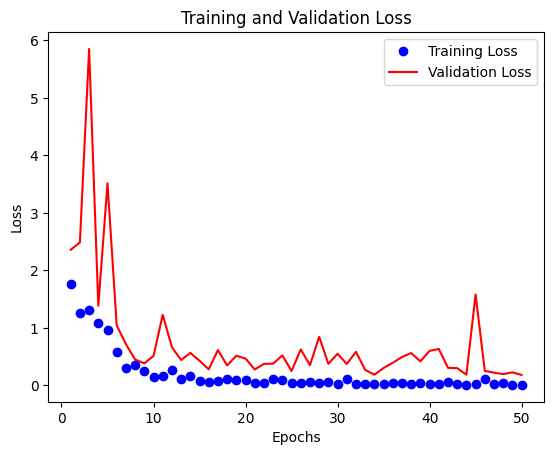

In [42]:
training_loss = history1.history['loss']
validation_loss = history1.history['val_loss']
epochs = range(1, len(training_loss) + 1)

plt.plot(epochs, training_loss, 'bo', label='Training Loss')
plt.plot(epochs, validation_loss, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

[[104   0   0   0   0   1   0   1   1   2   0   0   0]
 [  1  98   0   0   0   0   1   0   0   0   0   0   0]
 [  0   1  99   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0  88   1   1   0   0   0   0   1   4   0]
 [  0   0   0   0 428   1   7   2   0   1   6   0   0]
 [  0   2   1   0   3 265   5   2   0   0   1   0   0]
 [  0   0   0   0   2   0 150   2   1   2   0   0   0]
 [  1   0   0   0   3   0   2 422   1  12   0   0   0]
 [  3   0   3   0   1   1   0   4 207   0   0   1   1]
 [  0   0   0   0   2   2   0   4   1 460   0   0   0]
 [  0   0   0   0   2   1   3   3   3   0 396   0   0]
 [  0   0   0   4   0   0   0   0   0   0   1 274   3]
 [  0   1   1   0   0   0   0   0   0   0   0   0 137]]


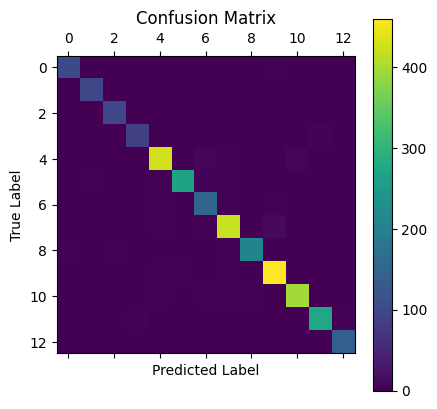

In [56]:
from sklearn.metrics import confusion_matrix

# Get predictions from your model

y_pred_classes = np.argmax(y_pred, axis=1)  # Convert one-hot to class labels

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Print or plot the confusion matrix (various ways to visualize it)
print(cm)

# Example using matplotlib for basic visualization
plt.matshow(cm)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.colorbar()
plt.show()

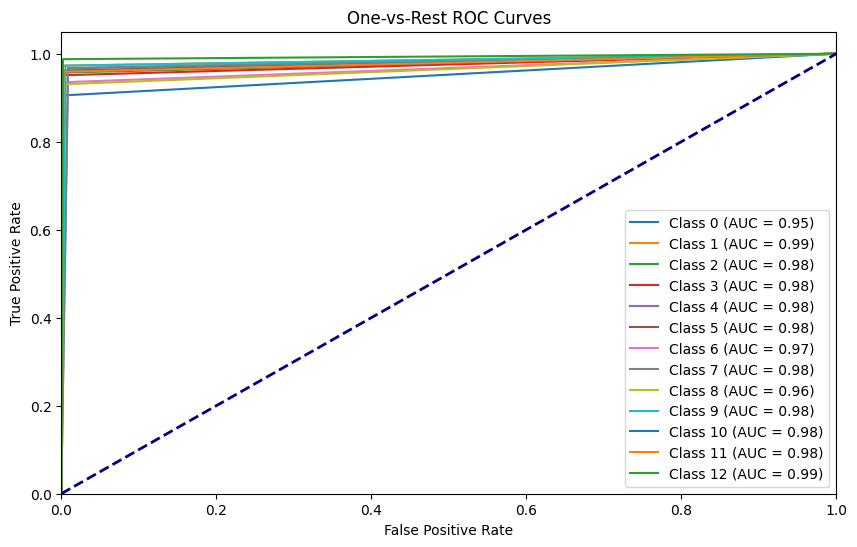

In [66]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming `y_test` are the true labels and `y_pred_probs` are the predicted probabilities
# Compute OvR ROC curve and ROC area for each class
plt.figure(figsize=(10, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test == i, y_pred_binary2[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.show()


In [43]:
model2.save('Octave90.h5')

In [44]:
model2.summary()

Model: "OctaveResNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_25      │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_217 (Conv2D) │ (None, 32, 32,    │      9,408 │ input_layer_25[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_217[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_78 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 16, 16,    │          0 │ re_lu_78[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_… │ (None, 8, 8, 64)  │          0 │ max_pooling2d_5[… │
│ (AveragePooling2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_218 (Conv2D) │ (None, 16, 16,    │      3,584 │ max_pooling2d_5[… │
│                     │ 56)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_219 (Conv2D) │ (None, 8, 8, 8)   │        512 │ average_pooling2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        224 │ conv2d_218[0][0]  │
│ (BatchNormalizatio… │ 56)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 8)   │         32 │ conv2d_219[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_79 (ReLU)     │ (None, 8, 8, 8)   │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_221 (Conv2D) │ (None, 8, 8, 56)  │      4,032 │ re_lu_79[1][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_… │ (None, 8, 8, 56)  │          0 │ re_lu_79[0][0]    │
│ (AveragePooling2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_220 (Conv2D) │ (None, 16, 16,    │     28,224 │ re_lu_79[0][0]    │
│                     │ 56)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_51    │ (None, 16, 16,    │          0 │ conv2d_221[0][0]  │
│ (UpSampling2D)      │ 56)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_222 (Conv2D) │ (None, 8, 8, 8)   │        576 │ re_lu_79[1][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_223 (Conv2D) │ (None, 8, 8, 8)   │      4,032 │ average_pooling2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_127 (Add)       │ (None, 16, 16,    │          0 │ conv2d_220[0][0], │
│                     │ 56)               │            │ up_sampling2d_51

 Total params: 70,657,129 (269.54 MB)

 Trainable params: 23,534,669 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

 Optimizer params: 47,069,340 (179.56 MB)

# Ensemble

In [45]:
octave_predictions = model2.predict(x_test)


 10/102 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step

W0000 00:00:1715620498.616412     189 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


102/102 ━━━━━━━━━━━━━━━━━━━━ 28s 115ms/step


W0000 00:00:1715620510.248624     189 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


In [46]:
combined_predictions = np.concatenate((vit_predictions, octave_predictions), axis=1)


In [47]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


In [48]:
meta_learner = LogisticRegression()
meta_learner.fit(combined_predictions, y_test)

# Make ensemble predictions
ensemble_predictions = meta_learner.predict(combined_predictions)

# Evaluate ensemble performance
ensemble_accuracy = accuracy_score(y_test, ensemble_predictions)
print(f'Ensemble Accuracy: {ensemble_accuracy}')

Ensemble Accuracy: 0.9719568567026194


/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [49]:
precision = precision_score(y_test, ensemble_predictions, average='weighted')
recall = recall_score(y_test, ensemble_predictions, average='weighted')
f1 = f1_score(y_test, ensemble_predictions, average='weighted')

# Generate a classification report
report = classification_report(y_test, ensemble_predictions)

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print('Classification Report:')
print(report)

Precision: 0.9720595760866177
Recall: 0.9719568567026194
F1-score: 0.9719597373307215
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.94       116
           1       0.99      0.98      0.99       110
           2       0.97      0.99      0.98        93
           3       0.99      0.96      0.98       102
           4       0.95      0.97      0.96       452
           5       0.97      0.98      0.97       262
           6       0.98      0.95      0.96       185
           7       0.97      0.97      0.97       429
           8       0.96      0.97      0.97       216
           9       0.98      0.98      0.98       484
          10       0.98      0.97      0.98       366
          11       0.97      0.98      0.98       269
          12       0.99      0.99      0.99       161

    accuracy                           0.97      3245
   macro avg       0.97      0.97      0.97      3245
weighted avg       0.97  

In [56]:
num_classes = np.max(ensemble_predictions) + 1  # Assuming class labels start from 0
y_pred_probs = np.eye(num_classes)[ensemble_predictions]

# Now, you can calculate ROC-AUC using the predicted probabilities
roc_auc = roc_auc_score(y_test, y_pred_probs, multi_class='ovr')
print(f'ROC-AUC: {roc_auc}')

ROC-AUC: 0.9843626354827915


[[109   0   1   0   2   0   1   3   0   0   0   0   0]
 [  1 108   1   0   0   0   0   0   0   0   0   0   0]
 [  0   1  92   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0  98   1   0   0   0   0   0   0   2   1]
 [  0   0   1   0 439   3   1   3   1   0   2   2   0]
 [  0   0   0   0   2 256   0   0   1   1   2   0   0]
 [  1   0   0   0   4   3 175   1   0   1   0   0   0]
 [  3   0   0   0   1   0   0 417   3   4   1   0   0]
 [  0   0   0   1   1   0   0   2 209   1   0   2   0]
 [  1   0   0   0   3   1   0   2   2 472   3   0   0]
 [  0   0   0   0   5   1   1   1   0   2 356   0   0]
 [  0   0   0   0   3   0   0   0   1   1   0 263   1]
 [  0   0   0   0   0   0   0   0   0   0   0   1 160]]


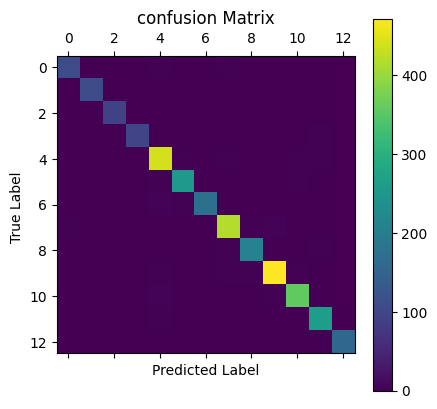

In [51]:
from sklearn.metrics import confusion_matrix

cm1 = confusion_matrix(y_test,ensemble_predictions)
print(cm1)
plt.matshow(cm1)
plt.title('confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label ')
plt.colorbar()
plt.show()

/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

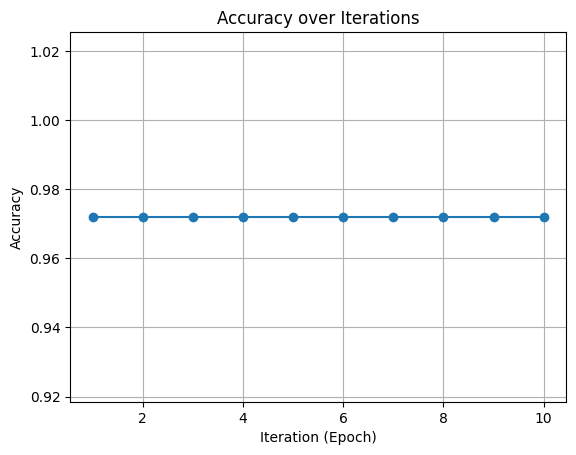

In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Initialize logistic regression model
meta_learner = LogisticRegression()

# Initialize lists to store accuracy and loss values
accuracy_values = []
num_epochs = 10
# Iterate over iterations (epochs)
for epoch in range(num_epochs):
    # Fit the logistic regression model on the combined predictions
    meta_learner.fit(combined_predictions, y_test)
    
    # Make ensemble predictions
    ensemble_predictions = meta_learner.predict(combined_predictions)
    
    # Calculate accuracy
    ensemble_accuracy = accuracy_score(y_test, ensemble_predictions)
    
    # Append accuracy to list
    accuracy_values.append(ensemble_accuracy)

# Plot accuracy over iterations
plt.plot(range(1, num_epochs + 1), accuracy_values, marker='o')
plt.xlabel('Iteration (Epoch)')
plt.ylabel('Accuracy')
plt.title('Accuracy over Iterations')
plt.grid(True)
plt.show()


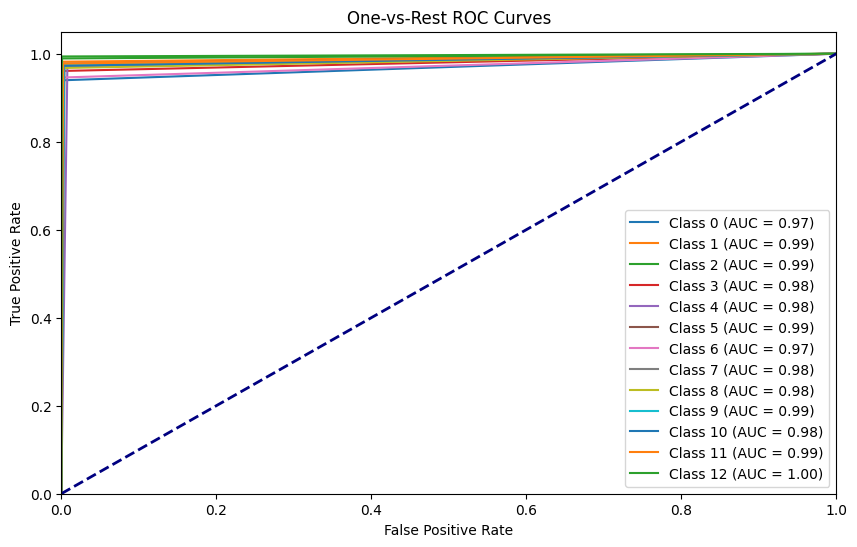

In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming you have trained your logistic regression model and obtained predicted probabilities
# logistic_regression_model = LogisticRegression()
# logistic_regression_model.fit(X_train, y_train)
# y_pred_proba = logistic_regression_model.predict_proba(X_test)

# Compute OvR ROC curve and ROC area for each class
plt.figure(figsize=(10, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test == i, y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.show()
